# 우리지역 인구통계 시각화

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# 한글 찍기
import platform

from matplotlib import font_manager, rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family = 'AppleGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
else:
    print('Unknown system... sorry~~~~')

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('datas/201912_202412_주민등록인구및세대현황_연간.csv',  encoding='cp949')
df.head()

,행정구역,2019년_거주자 인구수,2019년_세대수,2019년_세대당 인구,2019년_남자 인구수,2019년_여자 인구수,2019년_남여 비율,2020년_거주자 인구수,2020년_세대수,2020년_세대당 인구,...,2023년_세대당 인구,2023년_남자 인구수,2023년_여자 인구수,2023년_남여 비율,2024년_거주자 인구수,2024년_세대수,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율
0,서울특별시 서울특별시 광진구 (1121500000),"346,032","160,232",2.16,"167,631","178,401",0.94,"341,534","163,402",2.09,...,1.98,"159,930","173,074",0.92,"329,478","168,118",1.96,"157,942","171,536",0.92
1,서울특별시 광진구 화양동(1121571000),"21,568","15,725",1.37,"10,241","11,327",0.90,"22,178","16,646",1.33,...,1.28,"10,824","12,110",0.89,"22,629","17,801",1.27,"10,645","11,984",0.89
2,서울특별시 광진구 군자동(1121573000),"19,532","10,413",1.88,"9,627","9,905",0.97,"19,625","10,911",1.80,...,1.69,"9,324","9,599",0.97,"18,580","11,099",1.67,"9,126","9,454",0.97
3,서울특별시 광진구 중곡제1동(1121574000),"15,555","7,818",1.99,"7,619","7,936",0.96,"15,519","8,119",1.91,...,1.77,"7,165","7,991",0.90,"15,020","8,599",1.75,"7,118","7,902",0.90
4,서울특별시 광진구 중곡제2동(1121575000),"21,931","10,249",2.14,"10,509","11,422",0.92,"21,644","10,392",2.08,...,1.95,"9,564","10,812",0.88,"20,030","10,443",1.92,"9,426","10,604",0.89


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   행정구역           16 non-null     object 
 1   2019년_거주자 인구수  16 non-null     object 
 2   2019년_세대수      16 non-null     object 
 3   2019년_세대당 인구   16 non-null     float64
 4   2019년_남자 인구수   16 non-null     object 
 5   2019년_여자 인구수   16 non-null     object 
 6   2019년_남여 비율    16 non-null     float64
 7   2020년_거주자 인구수  16 non-null     object 
 8   2020년_세대수      16 non-null     object 
 9   2020년_세대당 인구   16 non-null     float64
 10  2020년_남자 인구수   16 non-null     object 
 11  2020년_여자 인구수   16 non-null     object 
 12  2020년_남여 비율    16 non-null     float64
 13  2021년_거주자 인구수  16 non-null     object 
 14  2021년_세대수      16 non-null     object 
 15  2021년_세대당 인구   16 non-null     float64
 16  2021년_남자 인구수   16 non-null     object 
 17  2021년_여자 인구수   16 non-null     object 
 18  2021년_남여 비율 

In [4]:
df.columns

Index(['행정구역', '2019년_거주자 인구수', '2019년_세대수', '2019년_세대당 인구', '2019년_남자 인구수',
       '2019년_여자 인구수', '2019년_남여 비율', '2020년_거주자 인구수', '2020년_세대수',
       '2020년_세대당 인구', '2020년_남자 인구수', '2020년_여자 인구수', '2020년_남여 비율',
       '2021년_거주자 인구수', '2021년_세대수', '2021년_세대당 인구', '2021년_남자 인구수',
       '2021년_여자 인구수', '2021년_남여 비율', '2022년_거주자 인구수', '2022년_세대수',
       '2022년_세대당 인구', '2022년_남자 인구수', '2022년_여자 인구수', '2022년_남여 비율',
       '2023년_거주자 인구수', '2023년_세대수', '2023년_세대당 인구', '2023년_남자 인구수',
       '2023년_여자 인구수', '2023년_남여 비율', '2024년_거주자 인구수', '2024년_세대수',
       '2024년_세대당 인구', '2024년_남자 인구수', '2024년_여자 인구수', '2024년_남여 비율'],
      dtype='object')

In [5]:
# 광진구 전체 요약 행만 선택
gwangjin_total = df.iloc[0]   # 0번째 행
gwangjin_total

행정구역             서울특별시 서울특별시 광진구 (1121500000)
2019년_거주자 인구수                         346,032
2019년_세대수                             160,232
2019년_세대당 인구                             2.16
2019년_남자 인구수                          167,631
2019년_여자 인구수                          178,401
2019년_남여 비율                              0.94
2020년_거주자 인구수                         341,534
2020년_세대수                             163,402
2020년_세대당 인구                             2.09
2020년_남자 인구수                          164,828
2020년_여자 인구수                          176,706
2020년_남여 비율                              0.93
2021년_거주자 인구수                         336,447
2021년_세대수                             165,305
2021년_세대당 인구                             2.04
2021년_남자 인구수                          162,207
2021년_여자 인구수                          174,240
2021년_남여 비율                              0.93
2022년_거주자 인구수                         334,978
2022년_세대수                             167,497
2022년_세대당 인구                      

In [6]:
# '거주자 인구수' 들어간 컬럼만 골라오기
pop_cols = [c for c in df.columns if '거주자 인구수' in c]
pop_cols

['2019년_거주자 인구수',
 '2020년_거주자 인구수',
 '2021년_거주자 인구수',
 '2022년_거주자 인구수',
 '2023년_거주자 인구수',
 '2024년_거주자 인구수']

In [7]:
# 광진구 전체 행에서 연도별 인구만 꺼내기 (Series)
pop_series = gwangjin_total[pop_cols]
pop_series

2019년_거주자 인구수    346,032
2020년_거주자 인구수    341,534
2021년_거주자 인구수    336,447
2022년_거주자 인구수    334,978
2023년_거주자 인구수    333,004
2024년_거주자 인구수    329,478
Name: 0, dtype: object

In [8]:
pop_series = gwangjin_total[pop_cols].str.replace(',', '').astype(int)

In [9]:
year_list = [int(c.split('년')[0]) for c in pop_cols]   # ['2019년_...' → 2019]
pop_values = pop_series.values.astype(int)

pop_df = pd.DataFrame({
    '연도': year_list,
    '거주자_인구수': pop_values
}).sort_values('연도')

pop_df

,연도,거주자_인구수
0,2019,346032
1,2020,341534
2,2021,336447
3,2022,334978
4,2023,333004
5,2024,329478


# 1. 연도별 인구 추세 그래프 그리기

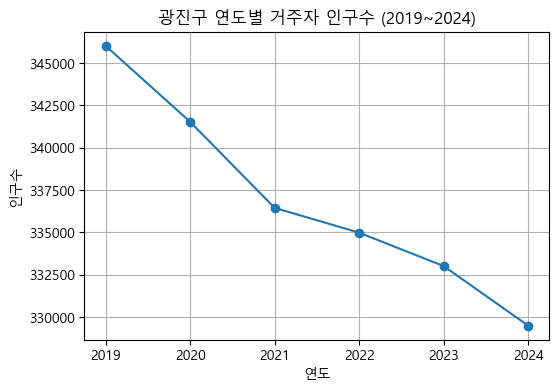

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(pop_df['연도'], pop_df['거주자_인구수'], marker='o')
plt.title("광진구 연도별 거주자 인구수 (2019~2024)")
plt.xlabel("연도")
plt.ylabel("인구수")
plt.grid(True)
plt.show()

## 한글 깨질 때(네모로 나올 때) 폰트 설정

In [21]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# Windows 기준 (맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"  # 폰트 위치
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 마이너스(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


그래프 해석
- 2019년 346k → 2024년 329k
- 약 17,000명 감소 (–4.9%), 지속적 감소 추세
- 서울 전체 인구 감소와 일치하지만 광진구는 특히 2021~2024 완만하나 꾸준한 하락

행정 인사이트
- 청년층 이동 + 고령화 + 교육·주거비 부담 등 복합적 영향
- 인구 감소 흐름이 명확해 → 지역활력 정책 필요

제안 포인트
- 청년 정착 유도(주거·일자리 패키지)
- 가족 단위 생활 인프라 확충(보육, 공원, 의료시설)
- 지역 상권 활성화 패키지(스타트업·소상공인 지원)

# 2. 동별 인구 분석(2024년 기준)

In [12]:
df.head()

,행정구역,2019년_거주자 인구수,2019년_세대수,2019년_세대당 인구,2019년_남자 인구수,2019년_여자 인구수,2019년_남여 비율,2020년_거주자 인구수,2020년_세대수,2020년_세대당 인구,...,2023년_세대당 인구,2023년_남자 인구수,2023년_여자 인구수,2023년_남여 비율,2024년_거주자 인구수,2024년_세대수,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율
0,서울특별시 서울특별시 광진구 (1121500000),"346,032","160,232",2.16,"167,631","178,401",0.94,"341,534","163,402",2.09,...,1.98,"159,930","173,074",0.92,"329,478","168,118",1.96,"157,942","171,536",0.92
1,서울특별시 광진구 화양동(1121571000),"21,568","15,725",1.37,"10,241","11,327",0.90,"22,178","16,646",1.33,...,1.28,"10,824","12,110",0.89,"22,629","17,801",1.27,"10,645","11,984",0.89
2,서울특별시 광진구 군자동(1121573000),"19,532","10,413",1.88,"9,627","9,905",0.97,"19,625","10,911",1.80,...,1.69,"9,324","9,599",0.97,"18,580","11,099",1.67,"9,126","9,454",0.97
3,서울특별시 광진구 중곡제1동(1121574000),"15,555","7,818",1.99,"7,619","7,936",0.96,"15,519","8,119",1.91,...,1.77,"7,165","7,991",0.90,"15,020","8,599",1.75,"7,118","7,902",0.90
4,서울특별시 광진구 중곡제2동(1121575000),"21,931","10,249",2.14,"10,509","11,422",0.92,"21,644","10,392",2.08,...,1.95,"9,564","10,812",0.88,"20,030","10,443",1.92,"9,426","10,604",0.89


In [13]:
# '광진구 전체' 행 제거하고 각 동만 남기기
dong_df = df.iloc[1:].copy()   # ← .copy() 추가

dong_df['2024년_거주자 인구수'] = (
    dong_df['2024년_거주자 인구수']
    .str.replace(',', '')
    .astype(int)
)

# 인구 많은 순 정렬
dong_sorted = dong_df[['행정구역','2024년_거주자 인구수']].sort_values('2024년_거주자 인구수', ascending=False)
dong_sorted.head()

,행정구역,2024년_거주자 인구수
8,서울특별시 광진구 광장동(1121581000),33554
15,서울특별시 광진구 구의제3동(1121587000),27452
6,서울특별시 광진구 중곡제4동(1121577000),27087
11,서울특별시 광진구 자양제3동(1121584000),26821
14,서울특별시 광진구 구의제2동(1121586000),25095


## 시각화

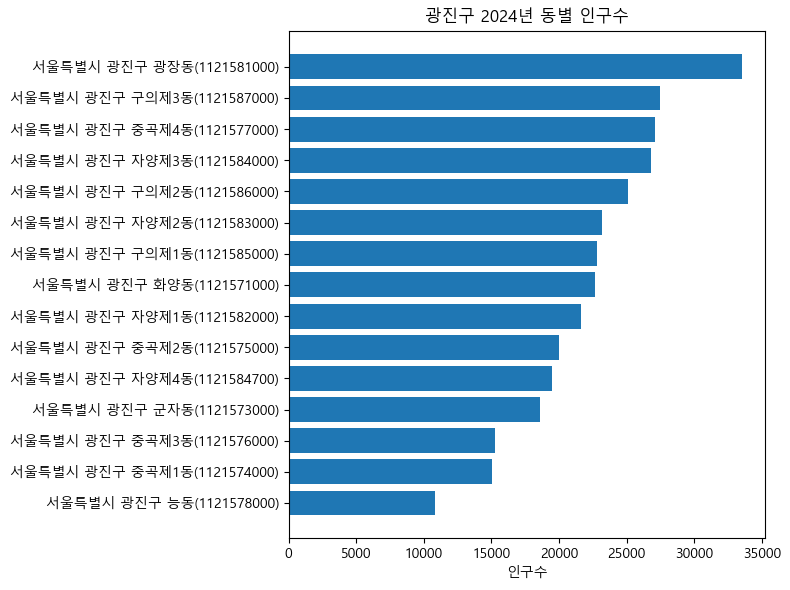

In [14]:
plt.figure(figsize=(8,6))
plt.barh(dong_sorted['행정구역'], dong_sorted['2024년_거주자 인구수'])
plt.title("광진구 2024년 동별 인구수")
plt.xlabel("인구수")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

그래프 해석
- 광장동이 압도적 1위 (34,000명 수준)
- 뒤이어 구의3동·중곡4동·자양3동이 높은 편
- 인구가 적은 동: 능동, 중곡1동, 군자동

행정 인사이트
- 광장동의 인구 집중 → 보육시설/교통/생활SOC 수요가 매우 큼
- 능동, 군자동 등 저밀도 동 → 고령화·공동화 위험지역 가능성

제안 포인트
- 광장동: 학교·보육·교통 혼잡 대응 정책 우선 검토
- 저밀도 동: 고령자 돌봄·주거 취약 지역 우선 지원
- 동별 인구 불균형 → 생활SOC 재배치·균형발전 전략 필요

# 3. 남녀 인구 추세(2019~2024)

In [15]:
# 광진구 전체(0번행)
gwangjin_total = df.iloc[0]

# 남자 컬럼
male_cols = [c for c in df.columns if '남자 인구수' in c]
female_cols = [c for c in df.columns if '여자 인구수' in c]

# 숫자로 변환
male_values = gwangjin_total[male_cols].str.replace(',', '').astype(int).values
female_values = gwangjin_total[female_cols].str.replace(',', '').astype(int).values

# 연도 리스트
years = [int(c.split('년')[0]) for c in male_cols]

# 데이터프레임 생성
sex_df = pd.DataFrame({
    '연도': years,
    '남자': male_values,
    '여자': female_values
}).sort_values('연도')

sex_df

,연도,남자,여자
0,2019,167631,178401
1,2020,164828,176706
2,2021,162207,174240
3,2022,161294,173684
4,2023,159930,173074
5,2024,157942,171536


## 시각화

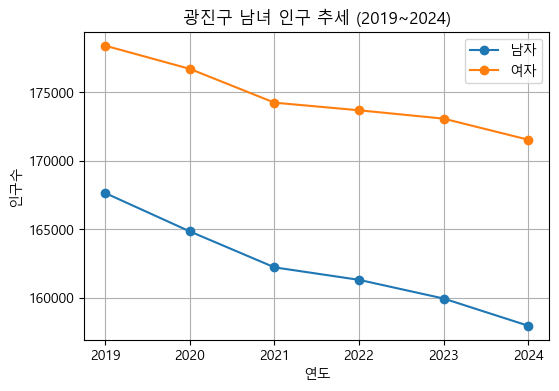

In [16]:
plt.figure(figsize=(6,4))
plt.plot(sex_df['연도'], sex_df['남자'], marker='o', label='남자')
plt.plot(sex_df['연도'], sex_df['여자'], marker='o', label='여자')
plt.title("광진구 남녀 인구 추세 (2019~2024)")
plt.xlabel("연도")
plt.ylabel("인구수")
plt.legend()
plt.grid(True)
plt.show()

그래프 해석
- 남자 인구: 169k → 158k (약 –6.5%)
- 여자 인구: 177k → 171k (약 –3.4%)
- 감소폭: 남성 > 여성
- 꾸준한 인구 유출 + 학령인구 감소 영향 반영

행정 인사이트
- 남성 인구 감소가 더 가파르다는 점은 군입대/이주/취업 이동에 더 민감한 청년층 이동을 반영
- 여성 인구는 상대적으로 안정적 → 주거 안정 요인 추정 가능

제안 포인트
- 청년 취업·교육 프로그램 확대 (직업교육, 취업매칭 등)
- 동별 청년층 이동량이 큰 지역은 교통·생활 지원 집중
- 건대·광장동 주변에 청년 커뮤니티/창업공간 조성

# 4. 연령대별 추세

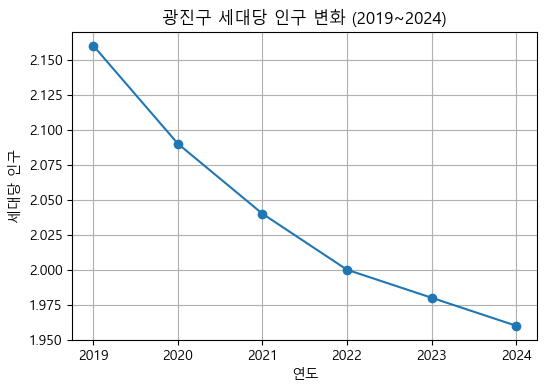

In [17]:
house_cols = [c for c in df.columns if '세대당 인구' in c]

# 세대당 인구는 이미 float 형태라 str.replace 필요 없음!
house_values = gwangjin_total[house_cols].astype(float)

house_years = [int(c.split('년')[0]) for c in house_cols]

house_df = pd.DataFrame({
    '연도': house_years,
    '세대당_인구': house_values.values
}).sort_values('연도')

plt.figure(figsize=(6,4))
plt.plot(house_df['연도'], house_df['세대당_인구'], marker='o')
plt.title("광진구 세대당 인구 변화 (2019~2024)")
plt.xlabel("연도")
plt.ylabel("세대당 인구")
plt.grid(True)
plt.show()

그래프 해석
- 2019년 2.15명 → 2024년 1.96명
- 5년간 세대당 인구가 꾸준히 감소
- 1~2인 가구 비중 증가라는 명확한 신호
- 서울 동부권 전반에서 나타나는 “초소형 가구화” 현상과 동일한 흐름

행정 인사이트
- 1~2인 가구는
    - 좁은 평수 주거 선호
    - 배달·편의 중심 소비 증가
    - 보건복지 필요 형태 변화(고립감, 정서지원 등)

제안 포인트
- 청년·1인가구 특화 주거정책(역세권 청년주택 연계)
- 1인가구 안심마을 조성
- 쓰레기 배출 시간 조정 등 생활SOC 미시정책 강화
- 소형문화/편의시설(무인카페·스터디룸·작은 도서관) 확대

# 5. 남녀 인구 비율 변화

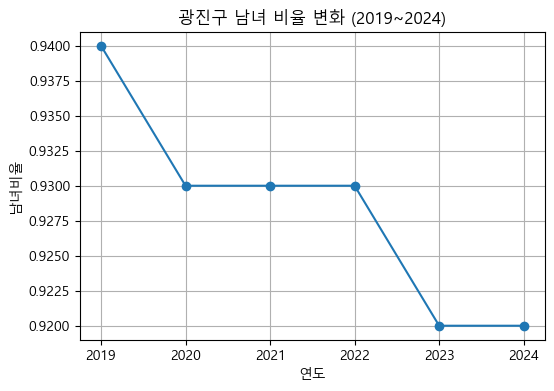

In [18]:
ratio_cols = [c for c in df.columns if '남여 비율' in c]

ratio_values = gwangjin_total[ratio_cols].astype(float)
ratio_years = [int(c.split('년')[0]) for c in ratio_cols]

ratio_df = pd.DataFrame({
    '연도': ratio_years,
    '남녀비율(남/여)': ratio_values.values
}).sort_values('연도')

plt.figure(figsize=(6,4))
plt.plot(ratio_df['연도'], ratio_df['남녀비율(남/여)'], marker='o')
plt.title("광진구 남녀 비율 변화 (2019~2024)")
plt.xlabel("연도")
plt.ylabel("남녀비율")
plt.grid(True)
plt.show()


전체적으로 남녀 비율(남/여)이 지속적으로 감소
→ 즉, 광진구는 여성 비중이 꾸준히 높아지는 구조

2019년 0.94 → 2024년 0.92
→ 남성 0.92명당 여성 1명

행정 인사이트
- 여성 비율 우세 지역 = 여성 1인 가구 증가, 안전·편의 인프라 중요성 상승
- 대학가 많은 지역 특성 고려 시(건대입구·세종대 주변) 여성 대학생/청년층 수요 반영 필요

  
제안 포인트
- 야간 귀가 동선 안전 강화(스마트보안등, CCTV 밀집지역 관리)
- 여성 1인가구 대상 생활안전 서비스 강화
- 여성 맞춤 커뮤니티·공간 조성 (스터디라운지·공유 부엌 등)

# 가구별

In [32]:
df.head()

,행정구역,2019년_거주자 인구수,2019년_세대수,2019년_세대당 인구,2019년_남자 인구수,2019년_여자 인구수,2019년_남여 비율,2020년_거주자 인구수,2020년_세대수,2020년_세대당 인구,...,2023년_세대당 인구,2023년_남자 인구수,2023년_여자 인구수,2023년_남여 비율,2024년_거주자 인구수,2024년_세대수,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율
0,서울특별시 서울특별시 광진구 (1121500000),"346,032","160,232",2.16,"167,631","178,401",0.94,"341,534","163,402",2.09,...,1.98,"159,930","173,074",0.92,"329,478","168,118",1.96,"157,942","171,536",0.92
1,서울특별시 광진구 화양동(1121571000),"21,568","15,725",1.37,"10,241","11,327",0.90,"22,178","16,646",1.33,...,1.28,"10,824","12,110",0.89,"22,629","17,801",1.27,"10,645","11,984",0.89
2,서울특별시 광진구 군자동(1121573000),"19,532","10,413",1.88,"9,627","9,905",0.97,"19,625","10,911",1.80,...,1.69,"9,324","9,599",0.97,"18,580","11,099",1.67,"9,126","9,454",0.97
3,서울특별시 광진구 중곡제1동(1121574000),"15,555","7,818",1.99,"7,619","7,936",0.96,"15,519","8,119",1.91,...,1.77,"7,165","7,991",0.90,"15,020","8,599",1.75,"7,118","7,902",0.90
4,서울특별시 광진구 중곡제2동(1121575000),"21,931","10,249",2.14,"10,509","11,422",0.92,"21,644","10,392",2.08,...,1.95,"9,564","10,812",0.88,"20,030","10,443",1.92,"9,426","10,604",0.89


In [25]:
# '2019년_세대수', '2019년_세대당 인구', '2020년_세대수','2020년_세대당 인구' ~24년까지

In [33]:
house_df.head()   #house_df = 연도별 세대당 인구

,연도,세대당_인구
0,2019,2.16
1,2020,2.09
2,2021,2.04
3,2022,2.00
4,2023,1.98


## 필요없는 부분 시작

In [ ]:
# # '광진구 전체' 행 제거하고 각 동만 남기기
# dong_df = df.iloc[1:].copy()   # ← .copy() 추가

# dong_df['2024년_거주자 인구수'] = (
#     dong_df['2024년_거주자 인구수']
#     .str.replace(',', '')
#     .astype(int)
# )

# # 인구 많은 순 정렬
# dong_sorted = dong_df[['행정구역','2024년_거주자 인구수']].sort_values('2024년_거주자 인구수', ascending=False)
# dong_sorted.head()

In [51]:
df_2019 = pd.read_csv('datas/2019_gwangjin.csv',  encoding='cp949')
df_2020 = pd.read_csv('datas/2020_gwangjin.csv',  encoding='cp949')
df_2021 = pd.read_csv('datas/2021_gwangjin.csv',  encoding='cp949')
df_2022 = pd.read_csv('datas/2022_gwangjin.csv',  encoding='cp949')
df_2023 = pd.read_csv('datas/2023_gwangjin.csv',  encoding='cp949')
df_2024 = pd.read_csv('datas/2024_gwangjin.csv',  encoding='cp949')

df_2019.head()

,행정구역,2019년_거주자 인구수,2019년_세대수,2019년_세대당 인구,2019년_남자 인구수,2019년_여자 인구수,2019년_남여 비율
0,서울특별시 서울특별시 광진구 (1121500000),"346,032","160,232",2.16,"167,631","178,401",0.94
1,서울특별시 광진구 화양동(1121571000),"21,568","15,725",1.37,"10,241","11,327",0.90
2,서울특별시 광진구 군자동(1121573000),"19,532","10,413",1.88,"9,627","9,905",0.97
3,서울특별시 광진구 중곡제1동(1121574000),"15,555","7,818",1.99,"7,619","7,936",0.96
4,서울특별시 광진구 중곡제2동(1121575000),"21,931","10,249",2.14,"10,509","11,422",0.92


In [52]:
dfs = [df_2019, df_2020, df_2021, df_2022, df_2023, df_2024]

dfs = [df.set_index('행정구역') for df in dfs]
df_2019, df_2020, df_2021, df_2022, df_2023, df_2024 = dfs

In [53]:
df_2019.iloc[:, [0]]

,2019년_거주자 인구수
행정구역,
서울특별시 서울특별시 광진구 (1121500000),"346,032"
서울특별시 광진구 화양동(1121571000),"21,568"
서울특별시 광진구 군자동(1121573000),"19,532"
서울특별시 광진구 중곡제1동(1121574000),"15,555"
서울특별시 광진구 중곡제2동(1121575000),"21,931"
서울특별시 광진구 중곡제3동(1121576000),"16,763"
서울특별시 광진구 중곡제4동(1121577000),"29,677"
서울특별시 광진구 능동(1121578000),"11,403"
서울특별시 광진구 광장동(1121581000),"35,519"


In [54]:
# total_df = 동별로 연도별 인구수
first_cols = [df.iloc[:, [0]] for df in dfs]
total_df = pd.concat(first_cols, axis=1)
total_df.head()

,2019년_거주자 인구수,2020년_거주자 인구수,2021년_거주자 인구수,2022년_거주자 인구수,2023년_거주자 인구수,2024년_거주자 인구수
행정구역,,,,,,
서울특별시 서울특별시 광진구 (1121500000),"346,032","341,534","336,447","334,978","333,004","329,478"
서울특별시 광진구 화양동(1121571000),"21,568","22,178","22,828","23,204","22,934","22,629"
서울특별시 광진구 군자동(1121573000),"19,532","19,625","19,373","19,282","18,923","18,580"
서울특별시 광진구 중곡제1동(1121574000),"15,555","15,519","15,335","15,225","15,156","15,020"
서울특별시 광진구 중곡제2동(1121575000),"21,931","21,644","21,222","20,848","20,376","20,030"


In [60]:
#CCTV_Seoul = CCTV_Seoul.rename(columns={'기관명':'구별'})  이름바꾸기
total_df = total_df.rename(columns={'2019년_거주자 인구수':'2019년'})
total_df = total_df.rename(columns={'2020년_거주자 인구수':'2020년'})
total_df = total_df.rename(columns={'2021년_거주자 인구수':'2021년'})
total_df = total_df.rename(columns={'2022년_거주자 인구수':'2022년'})
total_df = total_df.rename(columns={'2023년_거주자 인구수':'2023년'})
total_df = total_df.rename(columns={'2024년_거주자 인구수':'2024년'})
total_df.head()

,2019년,2020년,2021년,2022년,2023년,2024년
행정구역,,,,,,
서울특별시 서울특별시 광진구 (1121500000),"346,032","341,534","336,447","334,978","333,004","329,478"
서울특별시 광진구 화양동(1121571000),"21,568","22,178","22,828","23,204","22,934","22,629"
서울특별시 광진구 군자동(1121573000),"19,532","19,625","19,373","19,282","18,923","18,580"
서울특별시 광진구 중곡제1동(1121574000),"15,555","15,519","15,335","15,225","15,156","15,020"
서울특별시 광진구 중곡제2동(1121575000),"21,931","21,644","21,222","20,848","20,376","20,030"


In [56]:
# holds_df = 동별로 연도별 인구수
second_cols = [df.iloc[:, [2]] for df in dfs]
holds_df = pd.concat(second_cols, axis=1)
holds_df.head()

,2019년_세대당 인구,2020년_세대당 인구,2021년_세대당 인구,2022년_세대당 인구,2023년_세대당 인구,2024년_세대당 인구
행정구역,,,,,,
서울특별시 서울특별시 광진구 (1121500000),2.16,2.09,2.04,2.00,1.98,1.96
서울특별시 광진구 화양동(1121571000),1.37,1.33,1.30,1.29,1.28,1.27
서울특별시 광진구 군자동(1121573000),1.88,1.80,1.74,1.71,1.69,1.67
서울특별시 광진구 중곡제1동(1121574000),1.99,1.91,1.86,1.80,1.77,1.75
서울특별시 광진구 중곡제2동(1121575000),2.14,2.08,2.02,1.98,1.95,1.92


In [62]:
#CCTV_Seoul = CCTV_Seoul.rename(columns={'기관명':'구별'})  이름바꾸기
holds_df = holds_df.rename(columns={'2019년_세대당 인구':'2019년'})
holds_df = holds_df.rename(columns={'2020년_세대당 인구':'2020년'})
holds_df = holds_df.rename(columns={'2021년_세대당 인구':'2021년'})
holds_df = holds_df.rename(columns={'2022년_세대당 인구':'2022년'})
holds_df = holds_df.rename(columns={'2023년_세대당 인구':'2023년'})
holds_df = holds_df.rename(columns={'2024년_세대당 인구':'2024년'})
holds_df.head()

,2019년,2020년,2021년,2022년,2023년,2024년
행정구역,,,,,,
서울특별시 서울특별시 광진구 (1121500000),2.16,2.09,2.04,2.00,1.98,1.96
서울특별시 광진구 화양동(1121571000),1.37,1.33,1.30,1.29,1.28,1.27
서울특별시 광진구 군자동(1121573000),1.88,1.80,1.74,1.71,1.69,1.67
서울특별시 광진구 중곡제1동(1121574000),1.99,1.91,1.86,1.80,1.77,1.75
서울특별시 광진구 중곡제2동(1121575000),2.14,2.08,2.02,1.98,1.95,1.92


## 필요없는 부분 끝

In [66]:
df.head()

,행정구역,2019년_거주자 인구수,2019년_세대수,2019년_세대당 인구,2019년_남자 인구수,2019년_여자 인구수,2019년_남여 비율,2020년_거주자 인구수,2020년_세대수,2020년_세대당 인구,...,2023년_세대당 인구,2023년_남자 인구수,2023년_여자 인구수,2023년_남여 비율,2024년_거주자 인구수,2024년_세대수,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율
0,서울특별시 서울특별시 광진구 (1121500000),"346,032","160,232",2.16,"167,631","178,401",0.94,"341,534","163,402",2.09,...,1.98,"159,930","173,074",0.92,"329,478","168,118",1.96,"157,942","171,536",0.92
1,서울특별시 광진구 화양동(1121571000),"21,568","15,725",1.37,"10,241","11,327",0.90,"22,178","16,646",1.33,...,1.28,"10,824","12,110",0.89,"22,629","17,801",1.27,"10,645","11,984",0.89
2,서울특별시 광진구 군자동(1121573000),"19,532","10,413",1.88,"9,627","9,905",0.97,"19,625","10,911",1.80,...,1.69,"9,324","9,599",0.97,"18,580","11,099",1.67,"9,126","9,454",0.97
3,서울특별시 광진구 중곡제1동(1121574000),"15,555","7,818",1.99,"7,619","7,936",0.96,"15,519","8,119",1.91,...,1.77,"7,165","7,991",0.90,"15,020","8,599",1.75,"7,118","7,902",0.90
4,서울특별시 광진구 중곡제2동(1121575000),"21,931","10,249",2.14,"10,509","11,422",0.92,"21,644","10,392",2.08,...,1.95,"9,564","10,812",0.88,"20,030","10,443",1.92,"9,426","10,604",0.89


In [68]:
df2 = df.set_index('행정구역')

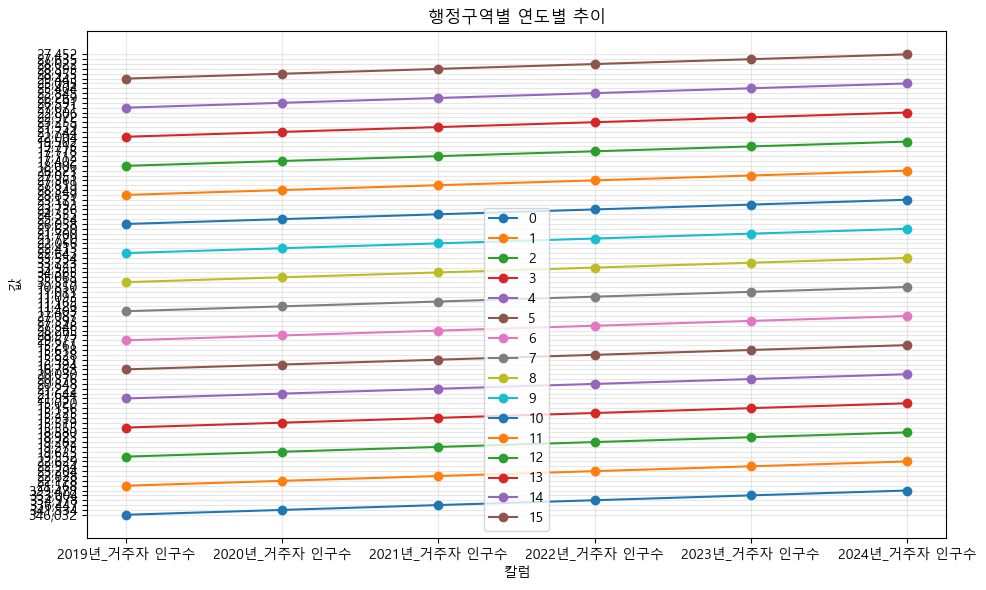

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# # 예시 데이터
# df = pd.DataFrame({
#     '2020': [100, 150, 120],
#     '2021': [110, 160, 130],
#     '2022': [120, 170, 140],
#     '2023': [130, 180, 150]
# }, index=['서울', '부산', '대구'])

# 특정 칼럼만 선택
selected_columns = ['2019년_거주자 인구수', '2020년_거주자 인구수', '2021년_거주자 인구수', '2022년_거주자 인구수','2023년_거주자 인구수','2024년_거주자 인구수']
df_selected = df[selected_columns]

# 그래프 그리기
plt.figure(figsize=(10, 6))

for idx in df_selected.index:
    plt.plot(df_selected.columns, df_selected.loc[idx], marker='o', label=idx)

plt.xlabel('칼럼')
plt.ylabel('값')
plt.title('행정구역별 연도별 추이')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()